# Auto-Annotate

### Automatically annotate images in a dataset using detection and segmentation models

- YOLO11v8 detection model: `docker/models/yolo26s_best.pt` ( pre-trained on EURO coins dataset )
- SAM2 segmentation model: `sam_b.pt` ( pre-trained on COCO dataset )

import required packages

- `os` : for interacting with the operating system
- `kagglehub` : for downloading datasets from Kaggle
- `random` : for selecting random files for visualization
- `pathlib` : for handling file paths
- `torch` : for checking GPU availability
- `ultralytics.data.annotator` : for auto-annotating images
- `ultralytics.data.utils` : for visualizing image annotations

In [10]:
import os
import random

import kagglehub
import torch
from ultralytics.data.annotator import auto_annotate
from ultralytics.data.utils import visualize_image_annotations

#### Download latest version ( EURO coins dataset  )

In [2]:
output_dir = "data_source/euro-coins-dataset"

path = kagglehub.dataset_download("janstaffa/segments",
                                  output_dir=output_dir)

print("Path to dataset files:", path)

100%|██████████| 10.6M/10.6M [00:01<00:00, 5.88MB/s]

Extracting files...


Path to dataset files: datasets


### Detect CUDA device

In [21]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

## Auto-annotate images in the dataset

- Using detection and segmentation models to automatically annotate images in the specified dataset directories.

In [22]:
paths = os.listdir("data_source")

cur_dir = os.path.join(os.getcwd(), "data_source")

for cur_path in paths:
    print(f'Auto-annotating {cur_path}')
    auto_annotate(data=os.path.join(cur_dir, cur_path, "images"),
                  device=device,  # use GPU if available
                  det_model="./models/yolo26s.pt",  # detection model
                  sam_model="./models/sam_b.pt",
                  classes=list(range(8)),
                  output_dir=os.path.join(cur_dir, cur_path, "segments")
                  )
    print(f'Auto-annotation completed for {cur_path}')

Auto-annotating euro-coins-dataset

image 1/150 C:\Users\Tymur\Projects\ComputerVision\Annotation\datasets\euro-coins-dataset\images\001.jpg: 640x480 1 1 cent, 1 2 cent, 1 5 cent, 5.5ms
image 2/150 C:\Users\Tymur\Projects\ComputerVision\Annotation\datasets\euro-coins-dataset\images\002.jpg: 640x480 1 10 cent, 11.2ms
image 3/150 C:\Users\Tymur\Projects\ComputerVision\Annotation\datasets\euro-coins-dataset\images\003.jpg: 640x480 1 2 cent, 6.2ms
image 4/150 C:\Users\Tymur\Projects\ComputerVision\Annotation\datasets\euro-coins-dataset\images\004.jpg: 640x480 1 1 cent, 5.6ms
image 5/150 C:\Users\Tymur\Projects\ComputerVision\Annotation\datasets\euro-coins-dataset\images\005.jpg: 640x480 1 10 cent, 5.9ms
image 6/150 C:\Users\Tymur\Projects\ComputerVision\Annotation\datasets\euro-coins-dataset\images\006.jpg: 640x480 1 20 cent, 5.4ms
image 7/150 C:\Users\Tymur\Projects\ComputerVision\Annotation\datasets\euro-coins-dataset\images\007.jpg: 640x480 1 5 cent, 2 50 cents, 5.8ms
image 8/150 C:\Use

### Convert segmentation labels to detection labels

In [23]:
def seg_to_det_label(seg_txt_path, det_txt_path):
    seg_txt_path = Path(seg_txt_path)
    det_txt_path = Path(det_txt_path)

    out_lines = []
    for line in seg_txt_path.read_text(encoding="utf-8").splitlines():
        vals = list(map(float, line.split()))
        cls = int(vals[0])

        if len(vals) == 5:
            out_lines.append(line)  # already detection format
            continue

        # segmentation polygon -> bbox (normalized coords)
        xs = vals[1::2]
        ys = vals[2::2]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)

        xc = (x_min + x_max) / 2
        yc = (y_min + y_max) / 2
        w = x_max - x_min
        h = y_max - y_min

        out_lines.append(f"{cls} {xc} {yc} {w} {h}")

    det_txt_path.write_text("\n".join(out_lines) + "\n", encoding="utf-8")

for dataset in paths:
    print(f'Converting segmentation labels to detection labels for {dataset}')
    for segment_file in os.listdir(os.path.join(cur_dir, dataset, "segments")):

        label_dir = os.path.join(cur_dir, dataset, "labels")
        if not os.path.exists(label_dir):
            os.makedirs(label_dir, exist_ok=True)

        print(f'Converting segmentation labels to detection labels for {segment_file}')
        seg_to_det_label(
            os.path.join(cur_dir, dataset, "segments", segment_file),
            os.path.join(cur_dir, dataset, "labels", segment_file)
        )
print("Conversion of segmentation labels to detection labels completed.")

Converting segmentation labels to detection labels for euro-coins-dataset
Converting segmentation labels to detection labels for 001.txt
Converting segmentation labels to detection labels for 002.txt
Converting segmentation labels to detection labels for 003.txt
Converting segmentation labels to detection labels for 004.txt
Converting segmentation labels to detection labels for 005.txt
Converting segmentation labels to detection labels for 006.txt
Converting segmentation labels to detection labels for 007.txt
Converting segmentation labels to detection labels for 008.txt
Converting segmentation labels to detection labels for 009.txt
Converting segmentation labels to detection labels for 010.txt
Converting segmentation labels to detection labels for 011.txt
Converting segmentation labels to detection labels for 012.txt
Converting segmentation labels to detection labels for 013.txt
Converting segmentation labels to detection labels for 014.txt
Converting segmentation labels to detection 

## Visualize random images with their annotations

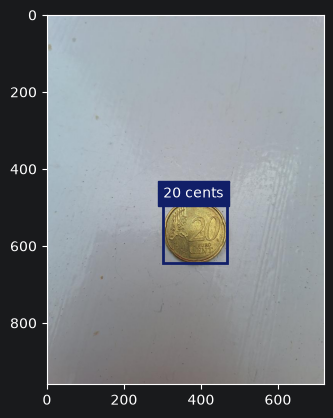

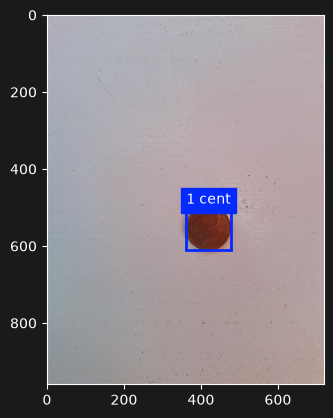

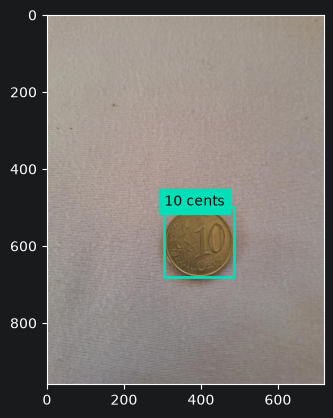

In [24]:
MAX_FILES = 3
ROOT_DIR = os.getcwd()
DATASET_DIR = os.path.join(ROOT_DIR, "data_source")

for data_set_dir in os.listdir(DATASET_DIR):
    IMG_DIR = os.path.join(DATASET_DIR, data_set_dir, "images")
    LABELS_DIR = os.path.join(DATASET_DIR, data_set_dir, "labels")

    for file in range(MAX_FILES):
        # select random file
        file = random.choice(os.listdir(IMG_DIR))

        visualize_image_annotations(
        image_path=os.path.join(IMG_DIR, file),
        txt_path=os.path.join(LABELS_DIR, file.replace(".jpg", ".txt")),
        label_map={0: "1 cent", 1: "2 cents", 2: "5 cents", 3: "10 cents", 4: "20 cents", 5: "50 cents", 6: "1 euro", 7: "2 euros"}
    )

In [9]:
from pathlib import Path

from datasets import load_dataset

ds = load_dataset("3v3r51nc3/eurocoin-vision-dataset", cache_dir='data_source/eurocoin-vision-dataset')

output_dir = Path('data_source/eurocoin-vision-dataset/images')
output_dir.mkdir(parents=True, exist_ok=True)

# Iterate and save
for idx, example in enumerate(ds['train']):
    image = example['image']  # PIL Image object
    image.save(output_dir / f"image_{idx}.jpg")

Resolving data files:   0%|          | 0/97 [00:00<?, ?it/s]